# 1. Project Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from scipy.stats import mode


In [2]:
# Set display options to show all columns/rows and suppress scientific notation for floats
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

import warnings
warnings.filterwarnings("ignore")

# --- Data Loading ---

In [3]:
# Assuming the file is named 'Insurance Data.xlsx' in the current working directory
try:
    data = pd.read_excel(r"D:\Downloads\Insurance_Data_50k.xlsx")
except FileNotFoundError:
    print("Error: Insurance Data.xlsx not found. Please ensure the file is in the correct directory.")


In [4]:
data.head()

,Age,Gender,Marital Status,Family Members,Education,Occupation,Job Title,Income,Current Product,Current Product Type,Current_Coverage,New Product Type,New_Coverage,Rating,Converted,Status
0,30.00,F,Divorced,2.00,LHS,SPT,PG,1.95,No,NO,-20709.00,INV,2155940.00,Cold,Converted,Converted
1,48.00,M,Divorced,3.00,LHS,SFT,OC,6.37,No,NO,-52383.00,TLE,991685.00,Warm,Converted,Converted
2,53.00,M,Married,4.00,NE,SPT,PG,5.82,Yes,NO,4018892.00,ANS,1972325.00,Cold,NotConverted,AS
3,45.00,M,Married,2.00,PD,SFT,RR,1.23,No,ANS,34644.00,ANS,3932434.00,Warm,NotConverted,Converted
4,37.00,M,Married,3.00,BD,SPT,BA,1.17,No,NO,27473.00,TLE,1984786.00,Hot,NotConverted,Converted


In [4]:
data.columns

Index(['Age', 'Gender', 'Marital Status', 'Family Members', 'Education',
       'Occupation', 'Job Title', 'Income', 'Current Product',
       'Current Product Type', 'Current_Coverage', 'New Product Type',
       'New_Coverage', 'Rating', 'Converted', 'Status'],
      dtype='object')

# --- Initial Data Prep ---

In [4]:
[re.sub(r'[\s/]+', '_', x.strip()) for x in data.columns]

['Age',
 'Gender',
 'Marital_Status',
 'Family_Members',
 'Education',
 'Occupation',
 'Job_Title',
 'Income',
 'Current_Product',
 'Current_Product_Type',
 'Current_Coverage',
 'New_Product_Type',
 'New_Coverage',
 'Rating',
 'Converted',
 'Status']

In [5]:
# Clean column names (replace spaces with underscores)
data.columns = [re.sub(r'[\s/]+', '_', x.strip()) for x in data.columns]

# Display initial shape and first few rows
print(f"Initial Shape: {data.shape}")
print("First 5 rows of the dataset:")
data.head()


Initial Shape: (50000, 16)
First 5 rows of the dataset:


,Age,Gender,Marital_Status,Family_Members,Education,Occupation,Job_Title,Income,Current_Product,Current_Product_Type,Current_Coverage,New_Product_Type,New_Coverage,Rating,Converted,Status
0,30.00,F,Divorced,2.00,LHS,SPT,PG,1.95,No,NO,-20709.00,INV,2155940.00,Cold,Converted,Converted
1,48.00,M,Divorced,3.00,LHS,SFT,OC,6.37,No,NO,-52383.00,TLE,991685.00,Warm,Converted,Converted
2,53.00,M,Married,4.00,NE,SPT,PG,5.82,Yes,NO,4018892.00,ANS,1972325.00,Cold,NotConverted,AS
3,45.00,M,Married,2.00,PD,SFT,RR,1.23,No,ANS,34644.00,ANS,3932434.00,Warm,NotConverted,Converted
4,37.00,M,Married,3.00,BD,SPT,BA,1.17,No,NO,27473.00,TLE,1984786.00,Hot,NotConverted,Converted


# 2. Data Understanding and Missing Values

Let's check for missing values to understand where we need to apply the cleaning strategies.

In [11]:
for col in data.columns:
    print("The unique values in each column", col)
    print(data[col].unique())

The unique values in each column Age
[30. 48. 53. 45. 37. 47. 58. 49. 40. 43. 33. 25. 20. 31. 59. 50. 27. 23.
 26. 56. 28. 35. 51. 22. 24. 39. 36. 38. 34. 42. 21. 54. 55. 32. 41. 18.
 57. 46. 52. 29. 60. 44. 19. nan]
The unique values in each column Gender
['F' 'M' nan]
The unique values in each column Marital_Status
['Divorced' 'Married' 'Single' nan]
The unique values in each column Family_Members
[ 2.  3.  4.  5.  7.  6.  9. 10.  8.  1. nan]
The unique values in each column Education
['LHS' 'NE' 'PD' 'BD' 'MD' 'UHS' nan]
The unique values in each column Occupation
['SPT' 'SFT' 'SE' nan]
The unique values in each column Job_Title
['PG' 'OC' 'RR' 'BA' 'FH' 'CB' 'PA' 'PR' 'OT' 'DD' 'CF' 'OM' nan]
The unique values in each column Income
[1.94818057 6.37291823 5.82038691 ... 2.5993835  5.04113262 1.53097298]
The unique values in each column Current_Product
['No' 'Yes' nan]
The unique values in each column Current_Product_Type
['NO' 'ANS' 'INV' 'PMT' 'END' 'TLE' nan]
The unique values in 

In [6]:
print("Missing values before cleaning:")
print(data.isnull().sum())

Missing values before cleaning:
Age                     22
Gender                  91
Marital_Status          21
Family_Members          11
Education               23
Occupation              22
Job_Title               62
Income                  49
Current_Product          9
Current_Product_Type    16
Current_Coverage        24
New_Product_Type        24
New_Coverage            64
Rating                  22
Converted               24
Status                   0
dtype: int64


All variables except Status have missing values, but the report indicates specific strategies for most of them.

## Data Engineering Strategy (from provided document)

We will implement the imputation based on the following general strategy:
1. **Simple Imputation (Mean/Median/Mode):** For most standalone variables.
2. **Complex Imputation (Group-wise Mean/Median/Mode):** For Income, Current_Coverage, and New_Coverage.
3. **Conditional Imputation (Business Logic):** For Current_Product, Current_Product_Type, Current_Coverage.
4. **Target Variable:** Drop missing Converted rows.
5. **Feature Selection:** Drop Gender and Marital_Status (as in the code snippet).

# 3. Data Cleaning and Preprocessing

## Handling Simple Missing Values (Age, Family_Members, Categorical)

### Age

Strategy: Calculate Mean and Median, Choose the lowest value (which is 38.97957101124495)

In [6]:
age_mean = data['Age'].mean()
age_median = data['Age'].median()
print(age_mean, age_median)

38.97957101124495 39.0


In [7]:
replacement = age_mean if age_mean < age_median else age_median
print(replacement)

38.97957101124495


In [8]:
data['Age'].fillna(replacement, inplace=True)
print(f"Age missing values filled with mean: {age_mean}")

Age missing values filled with mean: 38.97957101124495


In [9]:
data['Age'].isnull().sum()

np.int64(0)

### Family_Members

Missing Values were imputed by considering the minimum value between the mean
and median values which were calculated excluding the missing data

In [10]:
fm_mean = data['Family_Members'].mean()
fm_median = data['Family_Members'].median()
print(fm_mean, fm_median)
replacement = fm_mean if fm_mean < fm_median else fm_median
replacement

4.658804937086159 4.0


4.0

In [11]:
print("The value used fo replacement", replacement)
data['Family_Members'].fillna(replacement, inplace=True)

print(f"Family_Members missing values filled with median: {replacement}")

The value used fo replacement 4.0
Family_Members missing values filled with median: 4.0


In [20]:
# data.dtypes

### Education, Occupation, Job_Title, New_Product_Type, Rating: Replace with Mode

In [12]:
categorical_cols = ['Education', 'Occupation', 'Job_Title', 'New_Product_Type', 'Rating']
for col in categorical_cols:
    data[col].fillna(data[col].mode()[0], inplace=True)
    print(f"Variable {col} missing values filled with mode: {data[col].mode()[0]}")

Variable Education missing values filled with mode: BD
Variable Occupation missing values filled with mode: SPT
Variable Job_Title missing values filled with mode: FH
Variable New_Product_Type missing values filled with mode: ANS
Variable Rating missing values filled with mode: Cold


## Handling Income Missing Values (Grouped Mean/Median)

In [13]:
# Get mean and median grouped by Occupation
income_mean = data.groupby('Occupation')['Income'].mean()
income_median = data.groupby('Occupation')['Income'].median()

In [14]:
income_mean

Occupation
SE    4.94
SFT   4.92
SPT   4.99
Name: Income, dtype: float64

In [15]:
income_median

Occupation
SE    3.02
SFT   3.01
SPT   3.06
Name: Income, dtype: float64

In [19]:
# income_median['SE']

In [ ]:
# select the occ
# select mean
# select median
# check which is min
# store the min values
# will filter the where the occ is 'someting' and we have missing values in 'income'
# we fill the values by the stored min value

# will repeat the saem will remaing categpries


In [52]:
# for occ, mean in income_mean.items():
#     print("the occ is", occ)
#     print("The mean is", mean)
#     median  = income_median[occ]
#     print("the median is", median)

#     #JOB 2 : find the min 
#     imputation_value = min( mean, median)
#     print("the value used for filling the missingvalues is ", imputation_value)

#     condition = (data['Occupation'] == 'SE') & (data['Income'].isna())

#     data.loc[condition, 'Income'] = imputation_value

In [54]:
# c1 = (data['Occupation'] == 'SE')  & data['Income'].isna()

# data[c1]

In [55]:
# ser = pd.Series([10, 20, 30, 40, 50])
# ser

In [56]:
# ser.loc[[2, 4]] = 666

In [57]:
# # cross cehck 
# ser

In [58]:
# data.loc[c1, 'Income']

In [16]:
# Apply imputation logic
for occ, mean in income_mean.items():
    median = income_median[occ]

    # Choose the smaller of mean or median
    imputation_value = min(mean, median)

    # Find rows where Occupation matches and Income is missing
    mask = (data['Occupation'] == occ) & (data['Income'].isna())

    # Fill missing values
    data.loc[mask, 'Income'] = imputation_value

    print(f"Occupation: {occ}, Mean: {mean:.2f}, Median: {median:.2f}, Imputed with: {imputation_value:.2f}")

print(f"\nIncome missing values left: {data['Income'].isna().sum()}")

Occupation: SE, Mean: 4.94, Median: 3.02, Imputed with: 3.02
Occupation: SFT, Mean: 4.92, Median: 3.01, Imputed with: 3.01
Occupation: SPT, Mean: 4.99, Median: 3.06, Imputed with: 3.06

Income missing values left: 0


In [17]:
data['Income'].isnull().sum()

np.int64(0)

In [60]:
data.head()

,Age,Gender,Marital_Status,Family_Members,Education,Occupation,Job_Title,Income,Current_Product,Current_Product_Type,Current_Coverage,New_Product_Type,New_Coverage,Rating,Converted,Status
0,30.00,F,Divorced,2.00,LHS,SPT,PG,1.95,No,NO,-20709.00,INV,2155940.00,Cold,Converted,Converted
1,48.00,M,Divorced,3.00,LHS,SFT,OC,6.37,No,NO,-52383.00,TLE,991685.00,Warm,Converted,Converted
2,53.00,M,Married,4.00,NE,SPT,PG,5.82,Yes,NO,4018892.00,ANS,1972325.00,Cold,NotConverted,AS
3,45.00,M,Married,2.00,PD,SFT,RR,1.23,No,ANS,34644.00,ANS,3932434.00,Warm,NotConverted,Converted
4,37.00,M,Married,3.00,BD,SPT,BA,1.17,No,NO,27473.00,TLE,1984786.00,Hot,NotConverted,Converted


## Handling Interdependent Missing Values (Current Product, Type, Coverage)

This is a multi-step process requiring careful application of business logic.

### Step 1: Impute Current_Product (Yes/No)

**Strategy (from report):** If Current_Product_Type is 'NA' or Current_Coverage is 0, then Current_Product is 'No'. Otherwise, 'Yes'.

Note: Since we are filling in order, Current_Product_Type and Current_Coverage may still have missing values (NaN) at this stage.

#### Step 1: Impute Current_Product

In [19]:
c1 = data['Current_Product'].isna()
data[c1]

,Age,Gender,Marital_Status,Family_Members,Education,Occupation,Job_Title,Income,Current_Product,Current_Product_Type,Current_Coverage,New_Product_Type,New_Coverage,Rating,Converted,Status
3057,34.00,M,Married,2.00,BD,SPT,CB,9.27,NaN,NO,46806.00,ANS,2933667.00,Warm,Converted,Converted
4687,42.00,F,Married,2.00,MD,SPT,FH,9.35,NaN,NO,68337.00,ANS,2996273.00,Cold,Converted,Converted
6151,28.00,F,Married,7.00,UHS,SPT,FH,4.80,NaN,NO,984326.00,ANS,2967208.00,Hot,Converted,NW
18058,44.00,M,Married,9.00,BD,SE,OT,2.03,NaN,PMT,106040.00,ANS,15028047.00,Cold,NotConverted,QG
20282,34.00,F,Married,10.00,PD,SPT,FH,9.29,NaN,END,60401.00,END,4989096.00,Cold,NotConverted,AS
22396,56.00,F,Married,7.00,LHS,SPT,PG,3.53,NaN,PMT,-30483.00,ANS,2032073.00,Cold,NotConverted,PW
23094,39.00,F,Divorced,1.00,LHS,SE,PR,7.92,NaN,NO,3017127.00,INV,1057781.00,Hot,NotConverted,Converted
44320,22.00,M,Married,4.00,NE,SPT,FH,1.94,NaN,TLE,2936075.00,ANS,4081902.00,Cold,Converted,PN
46676,28.00,F,Divorced,4.00,BD,SPT,DD,6.53,NaN,ANS,-12088.00,ANS,1985458.00,Warm,NotConverted,QG


In [20]:
data[c1].index

Index([3057, 4687, 6151, 18058, 20282, 22396, 23094, 44320, 46676], dtype='int64')

In [18]:
# Identify rows where Current_Product is missing (NaN)
missing_prod_idx = data[data['Current_Product'].isna()].index
missing_prod_idx

Index([3057, 4687, 6151, 18058, 20282, 22396, 23094, 44320, 46676], dtype='int64')

In [35]:
# c1 = (data.loc[missing_prod_idx, 'Current_Product_Type'] == 'NO')

# c2 = (data.loc[missing_prod_idx, 'Current_Coverage'] == 0.0)



In [36]:
# data.loc[missing_prod_idx][c1 | c2]

In [37]:
# data.loc[missing_prod_idx][c1 | c2].index

##### simplified code

In [23]:
# data.loc[[3057, 4687, 6151, 18058, 20282, 22396, 23094, 44320, 46676]]

In [19]:
subset_data = data.loc[missing_prod_idx]
subset_data

,Age,Gender,Marital_Status,Family_Members,Education,Occupation,Job_Title,Income,Current_Product,Current_Product_Type,Current_Coverage,New_Product_Type,New_Coverage,Rating,Converted,Status
3057,34.00,M,Married,2.00,BD,SPT,CB,9.27,NaN,NO,46806.00,ANS,2933667.00,Warm,Converted,Converted
4687,42.00,F,Married,2.00,MD,SPT,FH,9.35,NaN,NO,68337.00,ANS,2996273.00,Cold,Converted,Converted
6151,28.00,F,Married,7.00,UHS,SPT,FH,4.80,NaN,NO,984326.00,ANS,2967208.00,Hot,Converted,NW
18058,44.00,M,Married,9.00,BD,SE,OT,2.03,NaN,PMT,106040.00,ANS,15028047.00,Cold,NotConverted,QG
20282,34.00,F,Married,10.00,PD,SPT,FH,9.29,NaN,END,60401.00,END,4989096.00,Cold,NotConverted,AS
22396,56.00,F,Married,7.00,LHS,SPT,PG,3.53,NaN,PMT,-30483.00,ANS,2032073.00,Cold,NotConverted,PW
23094,39.00,F,Divorced,1.00,LHS,SE,PR,7.92,NaN,NO,3017127.00,INV,1057781.00,Hot,NotConverted,Converted
44320,22.00,M,Married,4.00,NE,SPT,FH,1.94,NaN,TLE,2936075.00,ANS,4081902.00,Cold,Converted,PN
46676,28.00,F,Divorced,4.00,BD,SPT,DD,6.53,NaN,ANS,-12088.00,ANS,1985458.00,Warm,NotConverted,QG


In [20]:
subset_data = data.loc[missing_prod_idx]
is_product_type_no = (subset_data['Current_Product_Type'] == 'NO')
is_coverage_zero = (subset_data['Current_Coverage'] == 0.0)

In [21]:
subset_data[is_product_type_no| is_coverage_zero]

,Age,Gender,Marital_Status,Family_Members,Education,Occupation,Job_Title,Income,Current_Product,Current_Product_Type,Current_Coverage,New_Product_Type,New_Coverage,Rating,Converted,Status
3057,34.00,M,Married,2.00,BD,SPT,CB,9.27,NaN,NO,46806.00,ANS,2933667.00,Warm,Converted,Converted
4687,42.00,F,Married,2.00,MD,SPT,FH,9.35,NaN,NO,68337.00,ANS,2996273.00,Cold,Converted,Converted
6151,28.00,F,Married,7.00,UHS,SPT,FH,4.80,NaN,NO,984326.00,ANS,2967208.00,Hot,Converted,NW
23094,39.00,F,Divorced,1.00,LHS,SE,PR,7.92,NaN,NO,3017127.00,INV,1057781.00,Hot,NotConverted,Converted


In [22]:
indices_to_fix = subset_data[is_product_type_no| is_coverage_zero].index
indices_to_fix

Index([3057, 4687, 6151, 23094], dtype='int64')

In [23]:
data.loc[indices_to_fix, 'Current_Product'] = 'No'

In [24]:
# cross check 
data['Current_Product'].isnull().sum()

np.int64(5)

In [25]:
data['Current_Product'].isnull().sum()

np.int64(5)

In [26]:
# --- Scenario 2: Existing customer (Yes) ---
# If CP is still missing after above step -> Yes (implying non-NA type and non-zero coverage, even if those are NaN)
data['Current_Product'].fillna('Yes', inplace=True)

print(f"Current_Product missing values handled. New counts: \n{data['Current_Product'].value_counts()}")

Current_Product missing values handled. New counts: 
Current_Product
Yes    28442
No     21558
Name: count, dtype: int64


In [27]:
data['Current_Product'].isnull().sum()

np.int64(0)

#### Step 2: Impute Current_Product_Type
*   **Strategy (from report):** If `Current_Product` is 'No' or `Current_Coverage` is 0, then `Current_Product_Type` is 'NA' (using 'NO' as per the data). Otherwise, fill with Mode ('ANS').


In [28]:
# Step 2: Impute Current_Product_Type

### simple solution

In [29]:
product_type_col = 'Current_Product_Type'

In [30]:
product_type_col

'Current_Product_Type'

In [31]:
c1 = data[product_type_col].isna()
data[c1]

,Age,Gender,Marital_Status,Family_Members,Education,Occupation,Job_Title,Income,Current_Product,Current_Product_Type,Current_Coverage,New_Product_Type,New_Coverage,Rating,Converted,Status
542,57.00,F,Single,4.00,BD,SE,PG,9.48,Yes,NaN,15088033.00,ANS,15001049.00,Warm,Converted,ARS
605,26.00,F,Married,9.00,PD,SPT,FH,1.60,Yes,NaN,1984585.00,ANS,14899846.00,Cold,Converted,NW
1977,18.00,F,Single,5.00,NE,SE,FH,1.49,Yes,NaN,46075.00,TLE,4086659.00,Warm,NotConverted,NW
2037,37.00,F,Single,10.00,MD,SE,OM,1.15,Yes,NaN,-59423.00,INV,14989910.00,Hot,NotConverted,Converted
3051,24.00,F,Married,10.00,BD,SE,OT,10.02,Yes,NaN,3052414.00,TLE,2973748.00,Hot,NotConverted,Converted
6986,30.00,M,Married,2.00,LHS,SE,PG,9.44,Yes,NaN,14987708.00,TLE,1018979.00,Warm,NotConverted,AS
8947,21.00,F,Single,2.00,BD,SE,FH,9.89,No,NaN,-27264.00,ANS,3984153.00,Cold,NotConverted,Converted
9268,49.00,M,Divorced,1.00,MD,SPT,DD,1.07,No,NaN,929132.00,TLE,973267.00,Hot,Converted,AS
11706,48.00,F,Married,7.00,MD,SE,FH,4.31,Yes,NaN,15011187.00,ANS,14981939.00,Cold,Converted,Converted
15549,32.00,F,Divorced,3.00,NE,SE,PG,7.21,No,NaN,-2248.00,ANS,1976874.00,Hot,Converted,PW


In [32]:
product_type_col = 'Current_Product_Type'
nmissing_cpt_idx = data[data[product_type_col].isna()].index

In [33]:
nmissing_cpt_idx

Index([  542,   605,  1977,  2037,  3051,  6986,  8947,  9268, 11706, 15549,
       16402, 20439, 26622, 34146, 36138, 44087],
      dtype='int64')

In [34]:
subset_for_check = data.loc[nmissing_cpt_idx]

is_status_no = (subset_for_check['Current_Product'] == 'No')
is_coverage_zero = (subset_for_check['Current_Coverage'] == 0.0)

In [35]:
subset_for_check[is_status_no | is_coverage_zero]

,Age,Gender,Marital_Status,Family_Members,Education,Occupation,Job_Title,Income,Current_Product,Current_Product_Type,Current_Coverage,New_Product_Type,New_Coverage,Rating,Converted,Status
8947,21.00,F,Single,2.00,BD,SE,FH,9.89,No,NaN,-27264.00,ANS,3984153.00,Cold,NotConverted,Converted
9268,49.00,M,Divorced,1.00,MD,SPT,DD,1.07,No,NaN,929132.00,TLE,973267.00,Hot,Converted,AS
15549,32.00,F,Divorced,3.00,NE,SE,PG,7.21,No,NaN,-2248.00,ANS,1976874.00,Hot,Converted,PW
16402,23.00,M,Divorced,1.00,LHS,SPT,PG,2.97,No,NaN,999603.00,END,15068381.00,Cold,NotConverted,PS
26622,34.00,M,Single,5.00,BD,SPT,FH,7.21,No,NaN,15002045.00,END,1074398.00,Hot,NotConverted,PP
34146,51.00,F,Married,1.00,LHS,SPT,PG,2.00,No,NaN,-70360.00,ANS,1006880.00,Warm,Converted,Converted


In [36]:
indices_to_impute = subset_for_check[is_status_no | is_coverage_zero].index
indices_to_impute

Index([8947, 9268, 15549, 16402, 26622, 34146], dtype='int64')

In [37]:
indices_to_impute = subset_for_check[is_status_no | is_coverage_zero].index

data.loc[indices_to_impute, product_type_col] = 'NO'

In [38]:
# Cross ccheck
data['Current_Product_Type'].isnull().sum()

np.int64(10)

In [39]:
# data.loc[[8947, 9268, 15549, 16402, 26622, 34146]]

In [40]:
# # cross check
# data.loc[missing_cpt_idx][c1 | c2]

In [41]:
data['Current_Product_Type'].isnull().sum()

np.int64(10)

In [42]:
# --- Scenario 2: Existing customer -> Mode ---
# If CPT is still missing, fill with the mode of the *non-NO* types ('ANS' in the example)
remaining_missing_idx = data[data[product_type_col].isna()].index
remaining_missing_idx

Index([542, 605, 1977, 2037, 3051, 6986, 11706, 20439, 36138, 44087], dtype='int64')

In [43]:
data.loc[remaining_missing_idx]

,Age,Gender,Marital_Status,Family_Members,Education,Occupation,Job_Title,Income,Current_Product,Current_Product_Type,Current_Coverage,New_Product_Type,New_Coverage,Rating,Converted,Status
542,57.00,F,Single,4.00,BD,SE,PG,9.48,Yes,NaN,15088033.00,ANS,15001049.00,Warm,Converted,ARS
605,26.00,F,Married,9.00,PD,SPT,FH,1.60,Yes,NaN,1984585.00,ANS,14899846.00,Cold,Converted,NW
1977,18.00,F,Single,5.00,NE,SE,FH,1.49,Yes,NaN,46075.00,TLE,4086659.00,Warm,NotConverted,NW
2037,37.00,F,Single,10.00,MD,SE,OM,1.15,Yes,NaN,-59423.00,INV,14989910.00,Hot,NotConverted,Converted
3051,24.00,F,Married,10.00,BD,SE,OT,10.02,Yes,NaN,3052414.00,TLE,2973748.00,Hot,NotConverted,Converted
6986,30.00,M,Married,2.00,LHS,SE,PG,9.44,Yes,NaN,14987708.00,TLE,1018979.00,Warm,NotConverted,AS
11706,48.00,F,Married,7.00,MD,SE,FH,4.31,Yes,NaN,15011187.00,ANS,14981939.00,Cold,Converted,Converted
20439,41.00,M,Divorced,2.00,LHS,SE,PG,2.01,Yes,NaN,25045.00,INV,1038962.00,Cold,NotConverted,Converted
36138,44.00,F,Single,2.00,UHS,SE,FH,5.87,Yes,NaN,15050706.00,ANS,1022276.00,Hot,NotConverted,Converted
44087,21.00,F,Married,1.00,BD,SFT,DD,2.25,Yes,NaN,2037604.00,PMT,4061090.00,Cold,NotConverted,PW


In [ ]:
# non_no_data.empty

In [ ]:
# non_no_data = data[data[product_type_col] != 'NO'][product_type_col].dropna()
# mode_non_no = non_no_data.mode()[0] if not non_no_data.empty else 'ANS'
# mode_non_no

In [ ]:
# # Calculate mode of non-NO types
# non_no_data = data[data[product_type_col] != 'NO'][product_type_col].dropna()
# mode_non_no = non_no_data.mode()[0] if not non_no_data.empty else 'ANS' # Use ANS as default

# data.loc[remaining_missing_idx, product_type_col] = mode_non_no

# print(f"Current_Product_Type missing values handled. New counts: \n{data[product_type_col].value_counts()}")

In [44]:
data['Current_Product_Type'].mode()[0] # from this we could see most of the customers are new customers 

'NO'

To get the proper mode value we need to eliminate the new customers from the data

As we know, where the cusrrent product type is 'NO', which means they are new customers

In [45]:
c1 = data['Current_Product_Type'] != 'NO'

data[c1].head()

,Age,Gender,Marital_Status,Family_Members,Education,Occupation,Job_Title,Income,Current_Product,Current_Product_Type,Current_Coverage,New_Product_Type,New_Coverage,Rating,Converted,Status
3,45.00,M,Married,2.00,PD,SFT,RR,1.23,No,ANS,34644.00,ANS,3932434.00,Warm,NotConverted,Converted
6,58.00,F,Married,2.00,LHS,SE,RR,8.98,Yes,INV,19557.00,END,985299.00,Hot,NotConverted,PS
7,49.00,F,Divorced,7.00,LHS,SE,PG,9.53,No,PMT,59030.00,END,1022635.00,Cold,NotConverted,Converted
8,40.00,F,Married,6.00,PD,SPT,FH,1.47,Yes,ANS,15004736.00,TLE,2946612.00,Hot,Converted,PS
10,33.00,F,Married,5.00,UHS,SE,BA,2.28,Yes,END,2073883.00,ANS,14965529.00,Warm,NotConverted,NW


In [46]:
existing_customers = data[c1]

In [47]:
type(existing_customers)

pandas.core.frame.DataFrame

In [48]:
existing_customers['Current_Product_Type'].mode()

0    ANS
Name: Current_Product_Type, dtype: object

In [49]:
existing_customers['Current_Product_Type'].mode()[0]

'ANS'

In [50]:
data['Current_Product_Type'].fillna(existing_customers['Current_Product_Type'].mode()[0], inplace =  True)

In [51]:
# data['Current_Product_Type'].fillna(data[(data['Current_Product_Type'] != 'NO')]['Current_Product_Type'].mode()[0], inplace =  True)

In [52]:
# lets cross chechk the missing values
data['Current_Product_Type'].isnull().sum()

np.int64(0)

#### Step 3: Impute Current_Coverage

*   **Strategy (from report):** If `Current_Product` is 'No' or `Current_Product_Type` is 'NA' (NO), then `Current_Coverage` is 0. Otherwise, calculate Mean/Median for the `Current_Product_Type` and fill with the lowest of the two.


In [53]:
 data[data['Current_Coverage'].isna()]

,Age,Gender,Marital_Status,Family_Members,Education,Occupation,Job_Title,Income,Current_Product,Current_Product_Type,Current_Coverage,New_Product_Type,New_Coverage,Rating,Converted,Status
533,58.00,M,Married,7.00,BD,SPT,PR,6.94,No,NO,NaN,TLE,979835.00,Cold,Converted,QG
937,51.00,F,Divorced,8.00,BD,SPT,PG,1.49,No,ANS,NaN,INV,14975006.00,Cold,Converted,PW
5288,55.00,F,Married,9.00,LHS,SE,FH,2.89,Yes,NO,NaN,PMT,1092594.00,Cold,NotConverted,Converted
12729,56.00,M,Single,2.00,UHS,SPT,PR,2.24,No,NO,NaN,ANS,2937499.00,Warm,NotConverted,ARS
12789,33.00,F,Married,5.00,MD,SPT,FH,9.05,Yes,NO,NaN,PMT,1024521.00,Hot,NotConverted,NW
14781,24.00,M,Married,6.00,BD,SE,BA,1.25,No,PMT,NaN,TLE,1949558.00,Cold,NotConverted,PW
15757,56.00,M,Single,3.00,MD,SPT,OM,3.04,Yes,TLE,NaN,END,4084515.00,Warm,NotConverted,Converted
17876,57.00,M,Married,1.00,BD,SE,BA,9.78,No,NO,NaN,END,2077372.00,Warm,Converted,ARS
18632,18.00,F,Married,9.00,BD,SPT,PR,9.30,No,END,NaN,INV,1996759.00,Cold,Converted,PS
19063,45.00,M,Single,1.00,BD,SFT,PG,4.78,Yes,NO,NaN,TLE,14971228.00,Warm,Converted,AS


In [54]:
# Identify rows where Current_Coverage is missing (NaN)
missing_coverage_idx = data[data['Current_Coverage'].isna()].index
missing_coverage_idx

Index([  533,   937,  5288, 12729, 12789, 14781, 15757, 17876, 18632, 19063,
       19728, 21488, 21587, 26193, 32712, 32795, 36326, 40787, 40990, 44788,
       45842, 48819, 49595, 49812],
      dtype='int64')

In [55]:
# data.loc[missing_coverage_idx]

In [56]:
subset_cvg_miss_data = data.loc[missing_coverage_idx]
subset_cvg_miss_data

,Age,Gender,Marital_Status,Family_Members,Education,Occupation,Job_Title,Income,Current_Product,Current_Product_Type,Current_Coverage,New_Product_Type,New_Coverage,Rating,Converted,Status
533,58.00,M,Married,7.00,BD,SPT,PR,6.94,No,NO,NaN,TLE,979835.00,Cold,Converted,QG
937,51.00,F,Divorced,8.00,BD,SPT,PG,1.49,No,ANS,NaN,INV,14975006.00,Cold,Converted,PW
5288,55.00,F,Married,9.00,LHS,SE,FH,2.89,Yes,NO,NaN,PMT,1092594.00,Cold,NotConverted,Converted
12729,56.00,M,Single,2.00,UHS,SPT,PR,2.24,No,NO,NaN,ANS,2937499.00,Warm,NotConverted,ARS
12789,33.00,F,Married,5.00,MD,SPT,FH,9.05,Yes,NO,NaN,PMT,1024521.00,Hot,NotConverted,NW
14781,24.00,M,Married,6.00,BD,SE,BA,1.25,No,PMT,NaN,TLE,1949558.00,Cold,NotConverted,PW
15757,56.00,M,Single,3.00,MD,SPT,OM,3.04,Yes,TLE,NaN,END,4084515.00,Warm,NotConverted,Converted
17876,57.00,M,Married,1.00,BD,SE,BA,9.78,No,NO,NaN,END,2077372.00,Warm,Converted,ARS
18632,18.00,F,Married,9.00,BD,SPT,PR,9.30,No,END,NaN,INV,1996759.00,Cold,Converted,PS
19063,45.00,M,Single,1.00,BD,SFT,PG,4.78,Yes,NO,NaN,TLE,14971228.00,Warm,Converted,AS


In [100]:
# data['Current_Product_Type'].unique()

array(['NO', 'ANS', 'INV', 'PMT', 'END', 'TLE'], dtype=object)

In [101]:
# data['Current_Product'].unique()

array(['No', 'Yes'], dtype=object)

In [57]:
is_product_type_no = (subset_cvg_miss_data['Current_Product_Type'] == 'NO')
is_status_no = (subset_cvg_miss_data['Current_Product'] == 'No')

In [58]:
subset_cvg_miss_data[is_product_type_no| is_status_no]

,Age,Gender,Marital_Status,Family_Members,Education,Occupation,Job_Title,Income,Current_Product,Current_Product_Type,Current_Coverage,New_Product_Type,New_Coverage,Rating,Converted,Status
533,58.00,M,Married,7.00,BD,SPT,PR,6.94,No,NO,NaN,TLE,979835.00,Cold,Converted,QG
937,51.00,F,Divorced,8.00,BD,SPT,PG,1.49,No,ANS,NaN,INV,14975006.00,Cold,Converted,PW
5288,55.00,F,Married,9.00,LHS,SE,FH,2.89,Yes,NO,NaN,PMT,1092594.00,Cold,NotConverted,Converted
12729,56.00,M,Single,2.00,UHS,SPT,PR,2.24,No,NO,NaN,ANS,2937499.00,Warm,NotConverted,ARS
12789,33.00,F,Married,5.00,MD,SPT,FH,9.05,Yes,NO,NaN,PMT,1024521.00,Hot,NotConverted,NW
14781,24.00,M,Married,6.00,BD,SE,BA,1.25,No,PMT,NaN,TLE,1949558.00,Cold,NotConverted,PW
17876,57.00,M,Married,1.00,BD,SE,BA,9.78,No,NO,NaN,END,2077372.00,Warm,Converted,ARS
18632,18.00,F,Married,9.00,BD,SPT,PR,9.30,No,END,NaN,INV,1996759.00,Cold,Converted,PS
19063,45.00,M,Single,1.00,BD,SFT,PG,4.78,Yes,NO,NaN,TLE,14971228.00,Warm,Converted,AS
19728,44.00,M,Single,3.00,NE,SFT,RR,2.11,No,ANS,NaN,TLE,15064654.00,Warm,NotConverted,PP


In [59]:
indices_to_fix = subset_cvg_miss_data[is_product_type_no| is_status_no].index
indices_to_fix

Index([  533,   937,  5288, 12729, 12789, 14781, 17876, 18632, 19063, 19728,
       21587, 26193, 32795, 36326, 45842, 49595, 49812],
      dtype='int64')

In [67]:
# data.loc[[  533,   937,  5288, 12729, 12789, 14781, 17876, 18632, 19063, 19728,
#        21587, 26193, 32795, 36326, 45842, 49595, 49812]]

,Age,Gender,Marital_Status,Family_Members,Education,Occupation,Job_Title,Income,Current_Product,Current_Product_Type,Current_Coverage,New_Product_Type,New_Coverage,Rating,Converted,Status
533,58.00,M,Married,7.00,BD,SPT,PR,6.94,No,NO,NaN,TLE,979835.00,Cold,Converted,QG
937,51.00,F,Divorced,8.00,BD,SPT,PG,1.49,No,ANS,NaN,INV,14975006.00,Cold,Converted,PW
5288,55.00,F,Married,9.00,LHS,SE,FH,2.89,Yes,NO,NaN,PMT,1092594.00,Cold,NotConverted,Converted
12729,56.00,M,Single,2.00,UHS,SPT,PR,2.24,No,NO,NaN,ANS,2937499.00,Warm,NotConverted,ARS
12789,33.00,F,Married,5.00,MD,SPT,FH,9.05,Yes,NO,NaN,PMT,1024521.00,Hot,NotConverted,NW
14781,24.00,M,Married,6.00,BD,SE,BA,1.25,No,PMT,NaN,TLE,1949558.00,Cold,NotConverted,PW
17876,57.00,M,Married,1.00,BD,SE,BA,9.78,No,NO,NaN,END,2077372.00,Warm,Converted,ARS
18632,18.00,F,Married,9.00,BD,SPT,PR,9.30,No,END,NaN,INV,1996759.00,Cold,Converted,PS
19063,45.00,M,Single,1.00,BD,SFT,PG,4.78,Yes,NO,NaN,TLE,14971228.00,Warm,Converted,AS
19728,44.00,M,Single,3.00,NE,SFT,RR,2.11,No,ANS,NaN,TLE,15064654.00,Warm,NotConverted,PP


In [60]:
data.loc[indices_to_fix, 'Current_Coverage'] = 0.0

In [61]:
#  cross check 
# data.loc[[  533,   937,  5288, 12729, 12789, 14781, 17876, 18632, 19063, 19728,21587, 26193, 32795, 36326, 45842, 49595, 49812]]

In [62]:
data['Current_Coverage'].isnull().sum()

np.int64(7)

In [ ]:
################################################################################################

In [165]:
# c1 = data['Current_Coverage'].isnull()
# data[c1]

In [63]:
c1 = data['Current_Coverage'].isnull()
coverage_missing_idx = data[c1].index
# we have collected the row indexes whetre we have the missing values  in 'Current_Coverage'

In [64]:
coverage_missing_idx

Index([15757, 21488, 32712, 40787, 40990, 44788, 48819], dtype='int64')

In [65]:
# now will create a df with only missing values
coverage_missing_df = data.loc[coverage_missing_idx]

In [66]:
coverage_missing_df

,Age,Gender,Marital_Status,Family_Members,Education,Occupation,Job_Title,Income,Current_Product,Current_Product_Type,Current_Coverage,New_Product_Type,New_Coverage,Rating,Converted,Status
15757,56.00,M,Single,3.00,MD,SPT,OM,3.04,Yes,TLE,NaN,END,4084515.00,Warm,NotConverted,Converted
21488,41.00,M,Married,4.00,UHS,SPT,BA,2.20,Yes,ANS,NaN,ANS,15089955.00,Warm,NotConverted,Converted
32712,57.00,F,Single,10.00,BD,SPT,DD,1.52,Yes,END,NaN,TLE,1970579.00,Cold,Converted,Converted
40787,20.00,M,Married,4.00,PD,SPT,OM,3.00,Yes,END,NaN,INV,14955300.00,Cold,Converted,DR
40990,29.00,F,Married,5.00,PD,SPT,PG,7.96,Yes,PMT,NaN,INV,3010567.00,Cold,NotConverted,DR
44788,39.00,F,Married,6.00,MD,SE,DD,1.70,Yes,TLE,NaN,ANS,1942554.00,Cold,NotConverted,PP
48819,34.00,M,Divorced,1.00,BD,SPT,FH,9.28,Yes,INV,NaN,ANS,1141129.00,Cold,Converted,Converted


In [74]:
# # Now I want to check the where I have current product is 'No' or Current_Product_Type is 'NO'
# c1 = (coverage_missing_df['Current_Product'] == 'No')
# c2 = (coverage_missing_df['Current_Product_Type'] == 'NO')

# coverage_missing_df[c1 | c2]

In [75]:
# coverage_missing_df[c1 | c2].index

In [76]:
# # Step 3: Impute Current_Coverage
# coverage_col = 'Current_Coverage'

# # --- Scenario 1: No product -> 0 ---
# # If Current_Product is 'No' OR Current_Product_Type is 'NO'
# index_zero = data[(data[coverage_col].isna()) & ((data['Current_Product'] == 'No') | (data['Current_Product_Type'] == 'NO'))].index
# index_zero

In [77]:
# data.loc[index_zero, 'Current_Coverage']

In [78]:
# data.loc[index_zero, coverage_col] = 0.0

# print(f"Current_Coverage missing values filled with 0 for 'No' cases: {index_zero.shape[0]}")

In [79]:
# # now let check for the number of missing values in 'Current_Coverage'
# data['Current_Coverage'].isnull().sum()

np.int64(7)

In [81]:
# # step 1:
# remaining_missing_idx = data[data['Current_Coverage'].isna()].index
# remaining_missing_idx

Index([15757, 21488, 32712, 40787, 40990, 44788, 48819], dtype='int64')

In [82]:
# # step 2:
# non_no_data = data[data['Current_Product_Type'] != 'NO']
# non_no_data.head()

,Age,Gender,Marital_Status,Family_Members,Education,Occupation,Job_Title,Income,Current_Product,Current_Product_Type,Current_Coverage,New_Product_Type,New_Coverage,Rating,Converted,Status
3,45.00,M,Married,2.00,PD,SFT,RR,1.23,No,ANS,34644.00,ANS,3932434.00,Warm,NotConverted,Converted
6,58.00,F,Married,2.00,LHS,SE,RR,8.98,Yes,INV,19557.00,END,985299.00,Hot,NotConverted,PS
7,49.00,F,Divorced,7.00,LHS,SE,PG,9.53,No,PMT,59030.00,END,1022635.00,Cold,NotConverted,Converted
8,40.00,F,Married,6.00,PD,SPT,FH,1.47,Yes,ANS,15004736.00,TLE,2946612.00,Hot,Converted,PS
10,33.00,F,Married,5.00,UHS,SE,BA,2.28,Yes,END,2073883.00,ANS,14965529.00,Warm,NotConverted,NW


In [83]:
len(non_no_data)

28529

In [84]:
# # step 3a: we need find the grouped mean, median for 'Current_Coverage' by 'Current_Product_Type'
# coverage_mean = non_no_data.groupby('Current_Product_Type')['Current_Coverage'].mean()
# coverage_mean

Current_Product_Type
ANS   3625354.20
END   3487457.42
INV   3720713.47
PMT   3591767.70
TLE   3646926.78
Name: Current_Coverage, dtype: float64

In [85]:
# # step 3b:
# coverage_median = non_no_data.groupby('Current_Product_Type')['Current_Coverage'].median()
# coverage_median

Current_Product_Type
ANS   219070.00
END   118102.00
INV   924237.50
PMT   119062.00
TLE   911684.50
Name: Current_Coverage, dtype: float64

In [179]:
# # step 4:
# for ptype, mean_val in coverage_mean.items():
#     print(ptype)
#     print(mean_val)
#     # median_val = grp_median[ptype]
#     break

ANS
6594115.099344919


In [67]:
not True

False

In [68]:
# --- Scenario 2: Existing customers -> Grouped Mean/Median ---
coverage_col = 'Current_Coverage'
remaining_missing_idx = data[data[coverage_col].isna()].index

if not remaining_missing_idx.empty:
    # Calculate group mean/median for non-NO types
    non_no_data = data[data['Current_Product_Type'] != 'NO']

    # Calculate mean and median for the remaining non-NO groups
    grp_mean = non_no_data.groupby('Current_Product_Type')[coverage_col].mean()
    grp_median = non_no_data.groupby('Current_Product_Type')[coverage_col].median()

    for ptype, mean_val in grp_mean.items():
        median_val = grp_median[ptype]
        imputation_value = min(mean_val, median_val)

        # Find rows where coverage is missing and matches the product type
        mask = (data[coverage_col].isna()) & (data['Current_Product_Type'] == ptype)

        # Fill missing values
        data.loc[mask, coverage_col] = imputation_value
        print(f"Current_Coverage missing values filled for {ptype}: {imputation_value:.1f}")

print(f"Current_Coverage remaining NaNs: {data[coverage_col].isna().sum()}")

Current_Coverage missing values filled for ANS: 219070.0
Current_Coverage missing values filled for END: 118102.0
Current_Coverage missing values filled for INV: 924237.5
Current_Coverage missing values filled for PMT: 119062.0
Current_Coverage missing values filled for TLE: 911684.5
Current_Coverage remaining NaNs: 0


In [69]:
# crosds check 
data['Current_Coverage'].isnull().sum()

np.int64(0)

### 3.4. Handling `New_Coverage` Missing Values

Strategy: Group by `New_Product_Type`, calculate mean and median of `New_Coverage`, and fill missing values with the lower of the two for that group.

In [71]:
# New_Product_Type missing values were filled with 'ANS' in step 3.1
coverage_col = 'New_Coverage'
product_type_col = 'New_Product_Type'


In [72]:
# Calculate group mean/median
grp_mean = data.groupby(product_type_col)[coverage_col].mean()
grp_median = data.groupby(product_type_col)[coverage_col].median()

In [73]:
grp_mean

New_Product_Type
ANS   6066023.68
END   6146315.70
INV   6147366.88
PMT   5976171.40
TLE   6110191.54
Name: New_Coverage, dtype: float64

In [74]:
grp_median

New_Product_Type
ANS   2990033.00
END   2986221.50
INV   2992629.50
PMT   2973743.00
TLE   2984015.00
Name: New_Coverage, dtype: float64

In [75]:
# Apply imputation logic
for ptype, mean_val in grp_mean.items():
    median_val = grp_median[ptype]

    # Choose the smaller of mean or median
    imputation_value = min(mean_val, median_val)

    # Find rows where New_Coverage is missing and matches the product type
    mask = (data[coverage_col].isna()) & (data[product_type_col] == ptype)

    # Fill missing values
    data.loc[mask, coverage_col] = imputation_value

    print(f"New_Coverage missing values filled for {ptype}: {imputation_value:.1f}")

print(f"\nNew_Coverage remaining NaNs: {data[coverage_col].isna().sum()}")

New_Coverage missing values filled for ANS: 2990033.0
New_Coverage missing values filled for END: 2986221.5
New_Coverage missing values filled for INV: 2992629.5
New_Coverage missing values filled for PMT: 2973743.0
New_Coverage missing values filled for TLE: 2984015.0

New_Coverage remaining NaNs: 0


In [76]:
# cross check
data['New_Coverage'].isnull().sum()

np.int64(0)

# Handling Other Missing Values and Dropping Columns

In [77]:
data.isnull().sum()

Age                      0
Gender                  91
Marital_Status          21
Family_Members           0
Education                0
Occupation               0
Job_Title                0
Income                   0
Current_Product          0
Current_Product_Type     0
Current_Coverage         0
New_Product_Type         0
New_Coverage             0
Rating                   0
Converted               24
Status                   0
dtype: int64

### Handling Remaining Missing Values (Gender, Marital_Status)
The strategy for these variables is just to impute them with the Mode, which we will do now.

In [78]:
# Impute Gender and Marital_Status with Mode
data['Gender'].fillna(data['Gender'].mode()[0], inplace=True)
data['Marital_Status'].fillna(data['Marital_Status'].mode()[0], inplace=True)

print("Remaining categorical values imputed with Mode.")

Remaining categorical values imputed with Mode.


In [79]:
data.isnull().sum()

Age                      0
Gender                   0
Marital_Status           0
Family_Members           0
Education                0
Occupation               0
Job_Title                0
Income                   0
Current_Product          0
Current_Product_Type     0
Current_Coverage         0
New_Product_Type         0
New_Coverage             0
Rating                   0
Converted               24
Status                   0
dtype: int64

In [80]:
data.head()

,Age,Gender,Marital_Status,Family_Members,Education,Occupation,Job_Title,Income,Current_Product,Current_Product_Type,Current_Coverage,New_Product_Type,New_Coverage,Rating,Converted,Status
0,30.00,F,Divorced,2.00,LHS,SPT,PG,1.95,No,NO,-20709.00,INV,2155940.00,Cold,Converted,Converted
1,48.00,M,Divorced,3.00,LHS,SFT,OC,6.37,No,NO,-52383.00,TLE,991685.00,Warm,Converted,Converted
2,53.00,M,Married,4.00,NE,SPT,PG,5.82,Yes,NO,4018892.00,ANS,1972325.00,Cold,NotConverted,AS
3,45.00,M,Married,2.00,PD,SFT,RR,1.23,No,ANS,34644.00,ANS,3932434.00,Warm,NotConverted,Converted
4,37.00,M,Married,3.00,BD,SPT,BA,1.17,No,NO,27473.00,TLE,1984786.00,Hot,NotConverted,Converted


## Handling Target Variable Converted


building a predictive model for the missing values. Since we are doing exploratory analysis now, and Converted is the target, we will drop the rows with missing values to ensure a clean target variable for any later modeling/analysis.

In [81]:
# Drop rows where 'Converted' is missing
data.dropna(subset=['Converted'], inplace=True)
print(f"Dropped rows with missing 'Converted'. New shape: {data.shape}")

Dropped rows with missing 'Converted'. New shape: (49976, 16)


In [80]:
data.head()


,Age,Gender,Marital_Status,Family_Members,Education,Occupation,Job_Title,Income,Current_Product,Current_Product_Type,Current_Coverage,New_Product_Type,New_Coverage,Rating,Converted,Status
0,30.00,F,Divorced,2.00,LHS,SPT,PG,1.95,No,NO,-20709.00,INV,2155940.00,Cold,Converted,Converted
1,48.00,M,Divorced,3.00,LHS,SFT,OC,6.37,No,NO,-52383.00,TLE,991685.00,Warm,Converted,Converted
2,53.00,M,Married,4.00,NE,SPT,PG,5.82,Yes,NO,4018892.00,ANS,1972325.00,Cold,NotConverted,AS
3,45.00,M,Married,2.00,PD,SFT,RR,1.23,No,ANS,34644.00,ANS,3932434.00,Warm,NotConverted,Converted
4,37.00,M,Married,3.00,BD,SPT,BA,1.17,No,NO,27473.00,TLE,1984786.00,Hot,NotConverted,Converted


### Dropping Columns

Let's just drop the redundant Status column, which is an exact duplicate of Converted (Converted/NotConverted in both).

In [82]:
# Drop Status column as it's a duplicate of Converted
data.drop('Status', axis=1, inplace=True)
print("Dropped 'Status' column.")

Dropped 'Status' column.


In [83]:
data.shape

(49976, 15)

In [84]:
data.head()

,Age,Gender,Marital_Status,Family_Members,Education,Occupation,Job_Title,Income,Current_Product,Current_Product_Type,Current_Coverage,New_Product_Type,New_Coverage,Rating,Converted
0,30.00,F,Divorced,2.00,LHS,SPT,PG,1.95,No,NO,-20709.00,INV,2155940.00,Cold,Converted
1,48.00,M,Divorced,3.00,LHS,SFT,OC,6.37,No,NO,-52383.00,TLE,991685.00,Warm,Converted
2,53.00,M,Married,4.00,NE,SPT,PG,5.82,Yes,NO,4018892.00,ANS,1972325.00,Cold,NotConverted
3,45.00,M,Married,2.00,PD,SFT,RR,1.23,No,ANS,34644.00,ANS,3932434.00,Warm,NotConverted
4,37.00,M,Married,3.00,BD,SPT,BA,1.17,No,NO,27473.00,TLE,1984786.00,Hot,NotConverted


### Final Check for Missing Values

In [85]:
print("Missing values after Data Cleaning:")
print(data.isnull().sum())
print(f"Data shape after cleaning: {data.shape}")

Missing values after Data Cleaning:
Age                     0
Gender                  0
Marital_Status          0
Family_Members          0
Education               0
Occupation              0
Job_Title               0
Income                  0
Current_Product         0
Current_Product_Type    0
Current_Coverage        0
New_Product_Type        0
New_Coverage            0
Rating                  0
Converted               0
dtype: int64
Data shape after cleaning: (49976, 15)


In [86]:
data['Converted'].head()

0       Converted
1       Converted
2    NotConverted
3    NotConverted
4    NotConverted
Name: Converted, dtype: object

In [ ]:
###############################################################################################

In [87]:
data['Converted'].apply(lambda x: 1 if x == 'Converted' else 0).head()

0    1
1    1
2    0
3    0
4    0
Name: Converted, dtype: int64

In [88]:
# 1. Convert Target Variable 'Converted' to numeric
data['target'] = data['Converted'].apply(lambda x: 1 if x == 'Converted' else 0)
data.drop('Converted', axis=1, inplace=True)

# # 2. Convert remaining object columns to category codes (numerical encoding)
# cat_cols = data.select_dtypes(include='object').columns
# encoding_maps = {}

# for col in cat_cols:
#     data[col] = data[col].astype('category').cat.codes
#     print(f"Encoded '{col}' into numerical codes.")

# # Display the first few rows of the cleaned and encoded data
# print("\nFirst 5 rows of the processed data:")
# print(data.head())
# print(data.dtypes)

In [89]:
data.head()

,Age,Gender,Marital_Status,Family_Members,Education,Occupation,Job_Title,Income,Current_Product,Current_Product_Type,Current_Coverage,New_Product_Type,New_Coverage,Rating,target
0,30.00,F,Divorced,2.00,LHS,SPT,PG,1.95,No,NO,-20709.00,INV,2155940.00,Cold,1
1,48.00,M,Divorced,3.00,LHS,SFT,OC,6.37,No,NO,-52383.00,TLE,991685.00,Warm,1
2,53.00,M,Married,4.00,NE,SPT,PG,5.82,Yes,NO,4018892.00,ANS,1972325.00,Cold,0
3,45.00,M,Married,2.00,PD,SFT,RR,1.23,No,ANS,34644.00,ANS,3932434.00,Warm,0
4,37.00,M,Married,3.00,BD,SPT,BA,1.17,No,NO,27473.00,TLE,1984786.00,Hot,0


In [91]:
# let me save the cleanewd data
data.to_csv(r"C:\Users\RajendraPrasad\Downloads\cleaned_data_ins", index = False)

In [92]:
pip install ydata-profiling

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [93]:
# let me import the data that we have cleaned 
data = pd.read_csv(r"C:\Users\RajendraPrasad\Downloads\cleaned_data_ins")

In [94]:
# import ydata_profiling as pf
from ydata_profiling import ProfileReport 

In [95]:
profile = ProfileReport(data)
# profile

In [96]:
profile.to_file("my_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


%|                                                                                           | 0/15 [00:00<?, ?it/s]
%|███████████████████████████▋                                                       | 5/15 [00:00<00:00, 13.23it/s]
%|██████████████████████████████████████▋                                            | 7/15 [00:00<00:00, 12.71it/s]
%|█████████████████████████████████████████████████▊                                 | 9/15 [00:00<00:00, 10.13it/s]
100%|██████████████████████████████████████████████████████████████████████████████████| 15/15 [00:00<00:00, 15.76it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

## 2. Univariate Analysis Replication ##

--- Age Statistics ---
Average Age of Customers is 39 years


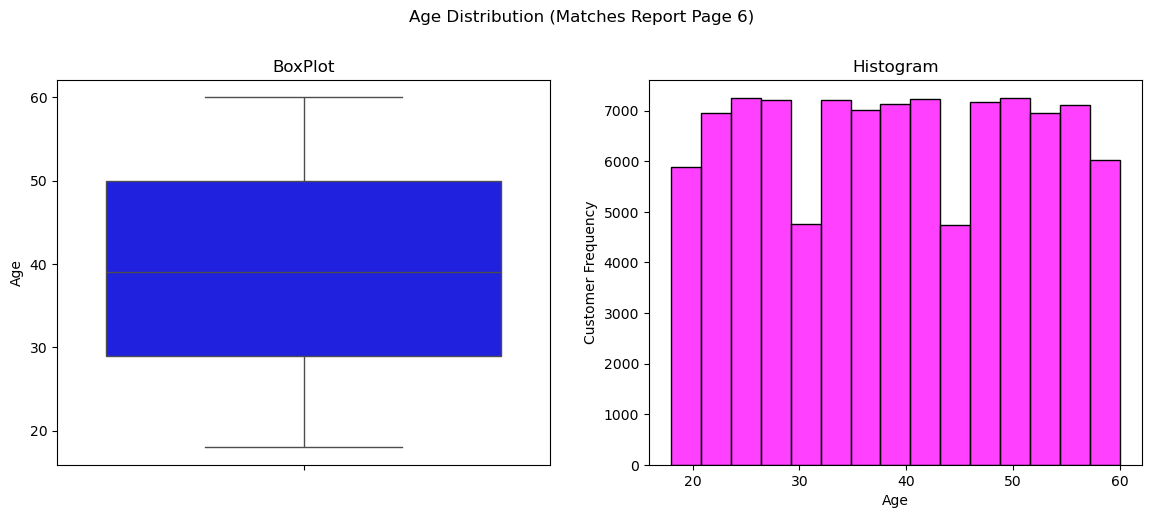


--- Gender Distribution ---
Gender
0    39875
1    60076


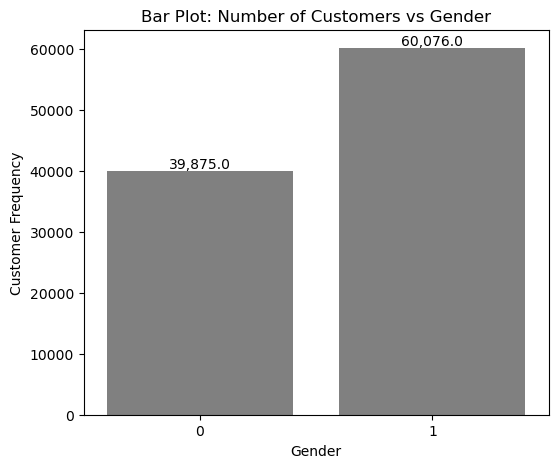


--- Marital Status Distribution ---
Marital_Status
0    23151
1    53966
2    22834


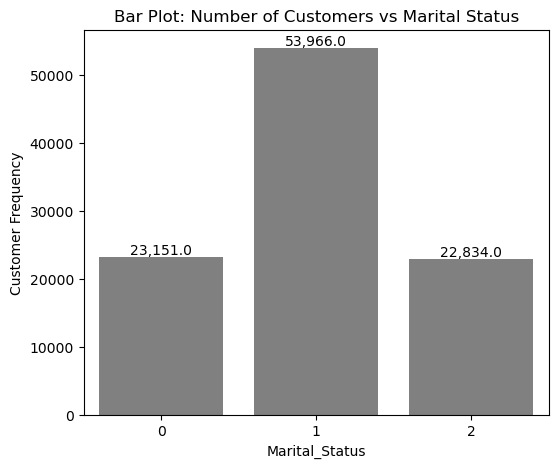


--- Education Distribution ---
Education
0    29616
1    13395
2    22530
3     7230
4    14739
5    12441


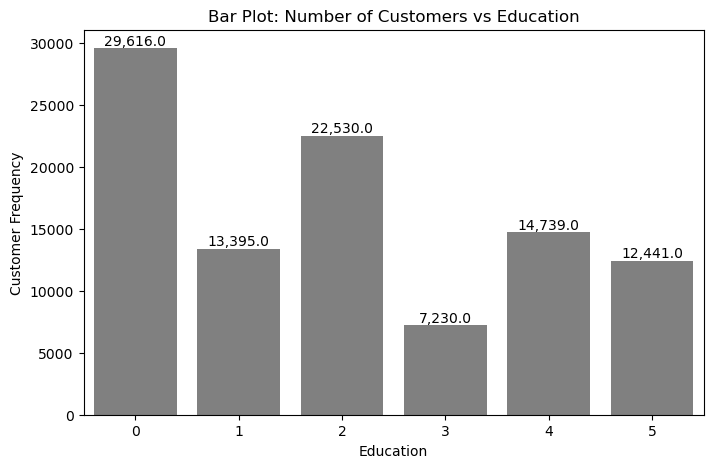


--- Rating Distribution ---
Rating
0    47576
1    22974
2    29401


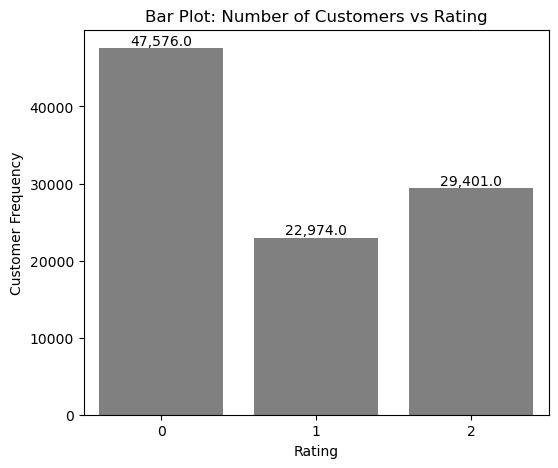

In [ ]:
# print(" Univariate Analysis Replication")

# # --- 2.1 Age Distribution () ---
# print("\n--- Age Statistics ---")
# print(f"Average Age of Customers is {data['Age'].mean():.0f} years")

# fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# fig.suptitle('Age Distribution (Matches Report Page 6)', y=1.02)

# # Box Plot
# sns.boxplot(y=data['Age'], ax=axes[0], color='blue')
# axes[0].set_title('BoxPlot')
# axes[0].set_ylabel('Age')

# # Histogram
# sns.histplot(data['Age'], bins=15, ax=axes[1], color='magenta', kde=False)
# axes[1].set_title('Histogram')
# axes[1].set_xlabel('Age')
# axes[1].set_ylabel('Customer Frequency')
# plt.show()


# # --- 2.2 Gender Distribution () ---
# print("\n--- Gender Distribution ---")
# gender_counts = data['Gender'].value_counts().sort_index()
# print(gender_counts.to_string())

# plt.figure(figsize=(6, 5))
# ax = sns.countplot(x='Gender', data=data, color='gray')
# plt.title('Bar Plot: Number of Customers vs Gender')
# plt.ylabel('Customer Frequency')
# plt.show()


# # --- 2.3 Marital Status Distribution () ---
# print("\n--- Marital Status Distribution ---")
# marital_counts = data['Marital_Status'].value_counts().sort_index()
# print(marital_counts.to_string())

# plt.figure(figsize=(6, 5))
# ax = sns.countplot(x='Marital_Status', data=data, color='gray')
# plt.title('Bar Plot: Number of Customers vs Marital Status')
# plt.ylabel('Customer Frequency')
# plt.show()


# # --- 2.4 Education Distribution () ---
# print("\n--- Education Distribution ---")
# edu_counts = data['Education'].value_counts().sort_index()
# print(edu_counts.to_string())

# plt.figure(figsize=(8, 5))
# ax = sns.countplot(x='Education', data=data, color='gray')
# plt.title('Bar Plot: Number of Customers vs Education')
# plt.ylabel('Customer Frequency')

# plt.show()


# # --- 2.5 Rating Distribution () ---
# print("\n--- Rating Distribution ---")
# rating_counts = data['Rating'].value_counts().sort_index()
# print(rating_counts.to_string())

# plt.figure(figsize=(6, 5))
# ax = sns.countplot(x='Rating', data=data, color='gray')
# plt.title('Bar Plot: Number of Customers vs Rating')
# plt.ylabel('Customer Frequency')

# plt.show()

In [ ]:
# 1. Overall Conversion Rate
total_customers = len(data)
conversion_rate = data['target'].mean() * 100
existing_customers_pct = (data['Current_Product'] == 1).sum() / total_customers * 100
new_customers_pct = (data['Current_Product'] == 0).sum() / total_customers * 100
male_pct = (data['Gender'] == 1).sum() / total_customers * 100
avg_age = data['Age'].mean()

print(f"Overall Conversion Rate (Converted=1): {conversion_rate:.2f}%")
print(f"Existing Customers: {existing_customers_pct:.2f}%")
print(f"New Customers (Targeted): {new_customers_pct:.2f}%")
print(f"Average Age: {avg_age:.2f}")
print(f"Percentage of Male Customers: {male_pct:.2f}%")

Overall Conversion Rate (Converted=1): 38.31%
Existing Customers: 57.13%
New Customers (Targeted): 42.87%
Average Age: 39.03
Percentage of Male Customers: 60.11%


# Analysis

In [4]:
# cleaned_data = pd.read_excel(r"D:\Naresh IT\fwdinsuranceproject (1)\Data_cleaned.xlsx")

In [6]:
# df = cleaned_data.copy()

In [114]:
df = data.copy()

In [115]:
df['Converted'] = df['target'].apply(lambda x: 'Converted' if x == 1 else 'NotConverted')

In [116]:
df.head()

,Age,Gender,Marital_Status,Family_Members,Education,Occupation,Job_Title,Income,Current_Product,Current_Product_Type,Current_Coverage,New_Product_Type,New_Coverage,Rating,target,Converted
0,30.00,F,Divorced,2.00,LHS,SPT,PG,1.95,No,NO,-20709.00,INV,2155940.00,Cold,1,Converted
1,48.00,M,Divorced,3.00,LHS,SFT,OC,6.37,No,NO,-52383.00,TLE,991685.00,Warm,1,Converted
2,53.00,M,Married,4.00,NE,SPT,PG,5.82,Yes,NO,4018892.00,ANS,1972325.00,Cold,0,NotConverted
3,45.00,M,Married,2.00,PD,SFT,RR,1.23,No,ANS,34644.00,ANS,3932434.00,Warm,0,NotConverted
4,37.00,M,Married,3.00,BD,SPT,BA,1.17,No,NO,27473.00,TLE,1984786.00,Hot,0,NotConverted


In [117]:
# 1A. Univariate Analysis - Target Variable 'Converted'

# Pandas: Value Counts and Percentage
conversion_counts = df['Converted'].value_counts()
conversion_percentages = df['Converted'].value_counts(normalize=True) * 100

print("--- Value Counts for 'Converted' ---")
print(conversion_counts)
print("\n--- Percentage of 'Converted' ---")
print(conversion_percentages)



--- Value Counts for 'Converted' ---
Converted
NotConverted    30897
Converted       19079
Name: count, dtype: int64

--- Percentage of 'Converted' ---
Converted
NotConverted   61.82
Converted      38.18
Name: proportion, dtype: float64


In [118]:
# Seaborn/Matplotlib: Bar Plot for visualization
plt.figure(figsize=(7, 5))
sns.countplot(x='Converted', data=df, palette='viridis')
plt.title('Conversion Status Distribution')
plt.xlabel('Conversion Status')
plt.ylabel('Number of Customers')
# plt.savefig('converted_univariate_plot.png')
plt.show()

In [121]:
import matplotlib.pyplot as plt
import seaborn as sns

In [122]:
# 1B. Univariate Analysis - Continuous Variable 'Income'

# Pandas: Descriptive Statistics
print("--- Descriptive Statistics for 'Income' ---")
print(df['Income'].describe())

# Seaborn/Matplotlib: Histogram for visualization
plt.figure(figsize=(8, 6))
sns.histplot(df['Income'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Customer Income')
plt.xlabel('Income (Standardized or Normalized)')
plt.ylabel('Frequency')
# plt.savefig('income_univariate_plot.png')
plt.show()

--- Descriptive Statistics for 'Income' ---
count   49976.00
mean        4.97
std         3.29
min         0.89
25%         2.04
50%         3.03
75%         9.11
max        10.12
Name: Income, dtype: float64


In [123]:
# 1C. Univariate Analysis - Categorical Variable 'Rating'

# Pandas: Value Counts and Percentage
rating_counts = df['Rating'].value_counts()
rating_percentages = df['Rating'].value_counts(normalize=True) * 100

print("--- Value Counts for 'Rating' ---")
print(rating_counts)
print("\n--- Percentage of 'Rating' ---")
print(rating_percentages)

# Seaborn/Matplotlib: Bar Plot for visualization
plt.figure(figsize=(7, 5))
sns.countplot(x='Rating', data=df, order=df['Rating'].value_counts().index, palette='rocket')
plt.title('Distribution of Customer Rating')
plt.xlabel('Rating (Cold, Warm, Hot)')
plt.ylabel('Number of Customers')
# plt.savefig('rating_univariate_plot.png')
plt.show()

--- Value Counts for 'Rating' ---
Rating
Cold    23886
Warm    14771
Hot     11319
Name: count, dtype: int64

--- Percentage of 'Rating' ---
Rating
Cold   47.79
Warm   29.56
Hot    22.65
Name: proportion, dtype: float64


In [124]:
#Bivariate Analysis - Categorical vs. Target: Rating vs. Converted

conversion_rate_by_rating = pd.crosstab(df['Rating'], df['Converted'], normalize='index') * 100

print("--- Conversion Percentage by Customer Rating ---")
print(conversion_rate_by_rating)

# Seaborn/Matplotlib: Stacked Bar Chart for visualization
rating_conversion_df = df.groupby(['Rating', 'Converted']).size().reset_index(name='Count')
total_by_rating = rating_conversion_df.groupby('Rating')['Count'].transform('sum')
rating_conversion_df['Percentage'] = rating_conversion_df['Count'] / total_by_rating * 100

plt.figure(figsize=(8, 6))
sns.barplot(
    x='Rating',
    y='Percentage',
    hue='Converted',
    data=rating_conversion_df,
    order=['Cold', 'Warm', 'Hot'], # Ensure order is logical
    palette='magma'
)
plt.title('Conversion Percentage by Customer Rating')
plt.xlabel('Customer Rating')
plt.ylabel('Percentage')
plt.legend(title='Converted')
# plt.savefig('rating_conversion_bivariate_plot.png')
plt.show()

--- Conversion Percentage by Customer Rating ---
Converted  Converted  NotConverted
Rating                            
Cold           37.54         62.46
Hot            39.60         60.40
Warm           38.12         61.88


Look at the 'Converted' column in the crosstab output. You can clearly see the conversion rate for Cold, Warm, and Hot customers. A good rating system should show a clear increase in the conversion rate as the rating moves from 'Cold' $\rightarrow$ 'Warm' $\rightarrow$ 'Hot'.

--- Age Descriptive Statistics Grouped by Conversion Status ---
                count  mean   std   min   25%   50%   75%   max
Converted                                                      
Converted    38323.00 37.22 11.65 18.00 27.00 36.00 47.00 60.00
NotConverted 61677.00 40.15 12.26 18.00 29.00 41.00 51.00 60.00


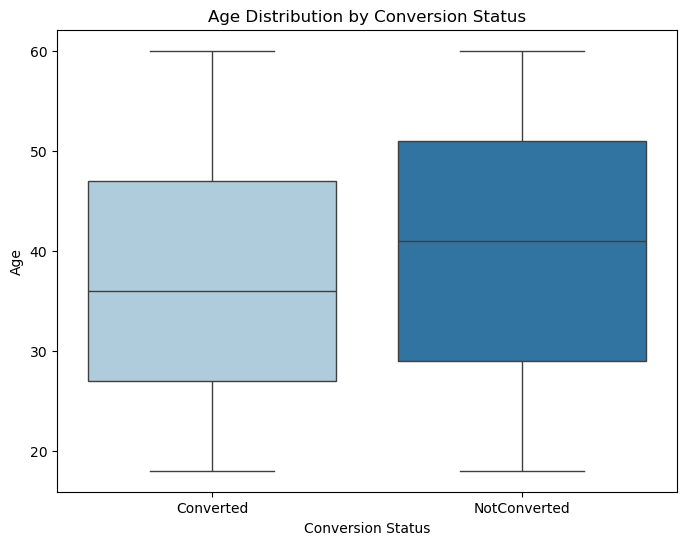

In [12]:
#  Bivariate Analysis - Continuous vs. Target: Age vs. Converted

# Pandas: Grouped Descriptive Statistics
print("--- Age Descriptive Statistics Grouped by Conversion Status ---")
print(df.groupby('Converted')['Age'].describe())

# Seaborn/Matplotlib: Box Plot for visualization
plt.figure(figsize=(8, 6))
sns.boxplot(x='Converted', y='Age', data=df, palette='Paired')
plt.title('Age Distribution by Conversion Status')
plt.xlabel('Conversion Status')
plt.ylabel('Age')
# plt.savefig('age_conversion_bivariate_plot.png')
plt.show()

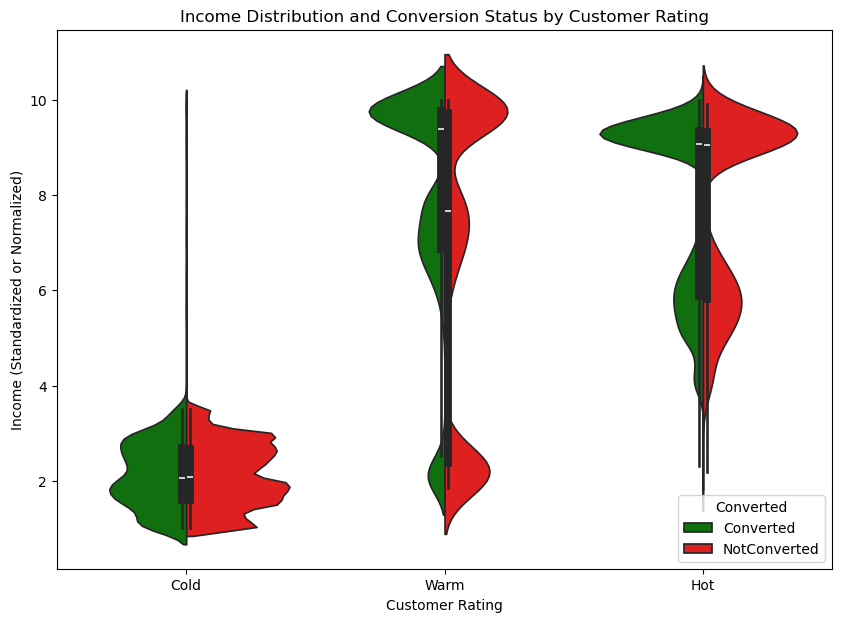

In [13]:
# 3. Multivariate Analysis - Income vs. Converted, grouped by Rating

# Seaborn/Matplotlib: Violin Plot for visualization
plt.figure(figsize=(10, 7))
sns.violinplot(
    x='Rating',
    y='Income',
    hue='Converted',
    data=df,
    order=['Cold', 'Warm', 'Hot'], # Ensure order is logical
    split=True, # Split the violins for better comparison
    palette={'Converted': 'green', 'NotConverted': 'red'}
)
plt.title('Income Distribution and Conversion Status by Customer Rating')
plt.xlabel('Customer Rating')
plt.ylabel('Income (Standardized or Normalized)')
plt.legend(title='Converted')
# plt.savefig('income_rating_conversion_multivariate_plot.png')
plt.show()

--- MEAN INCOME ANALYSIS: TOP EDUCATION AND EXISTING CUSTOMER STATUS ---
                                   count  mean  std  min  25%  50%  75%   max
Education Current_Product target                                             
MD        No              0      3857.00  3.40 2.66 1.50 1.89 2.28 2.89 10.00
                          1      5261.00  8.12 1.87 1.50 6.59 9.15 9.50 10.00
          Yes             0      7634.00  4.97 3.25 1.50 2.32 2.90 9.07 10.00
                          1      5778.00  8.22 1.92 1.50 6.79 9.24 9.60 10.00
PD        No              0      2461.00  3.38 2.60 1.50 1.90 2.32 2.86 10.00
                          1      3439.00  8.13 1.88 1.50 6.62 9.15 9.50 10.00
          Yes             0      4991.00  5.01 3.28 1.50 2.31 2.90 9.21 10.00
                          1      3848.00  8.18 1.94 1.50 6.78 9.23 9.58 10.00


ValueError: The palette dictionary is missing keys: {np.int64(0), np.int64(1)}

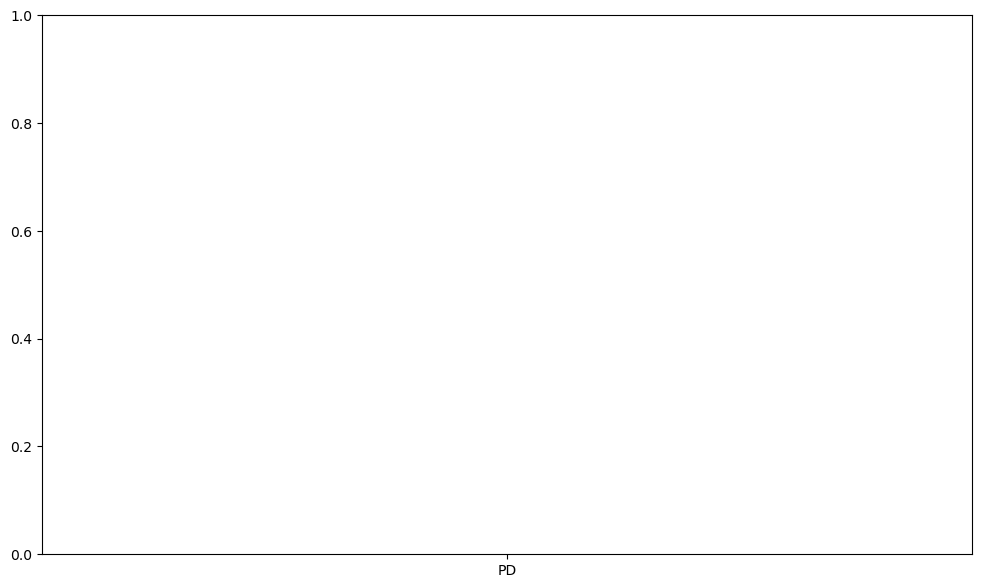

In [203]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset (assuming it is already loaded in the environment as 'df')
# If you run this code in a fresh environment, uncomment the line below:
df = pd.read_csv(r"C:\Users\vadla rajendraprasad\Downloads\cleaned_ins_data.csv")

# 1. Define the best-performing education levels based on Bivariate analysis
top_education_levels = ['PD', 'MD']
df_filtered = df[df['Education'].isin(top_education_levels)].copy()

# 2. Grouped statistics for the most actionable segment:
# Check the mean income for conversion status, grouped by Current_Product and Education
# This generates the exact numbers used to confirm the "High-Income converts" rule.
income_conversion_stats = df_filtered.groupby(['Education', 'Current_Product', 'target'])['Income'].describe()

print("--- MEAN INCOME ANALYSIS: TOP EDUCATION AND EXISTING CUSTOMER STATUS ---")
print(income_conversion_stats)

# 3. Seaborn/Matplotlib: Violin Plot for clear visualization
# This plot visually confirms that the 'Converted' group (green) has a higher income distribution.
plt.figure(figsize=(12, 7))
sns.violinplot(
    x='Education',
    y='Income',
    hue='target',
    data=df_filtered,
    split=True,
    inner='quartile', # Shows the median and quartiles
    palette={'target': 'green', 'NotConverted': 'red'},
    order=top_education_levels
)
plt.title('Income Distribution and Conversion Status for Top Education Levels (PD, MD)')
plt.xlabel('Education Level')
plt.ylabel('Income (Standardized or Normalized)')
plt.legend(title='Converted Status')
plt.savefig('multivariate_income_education_converted_plot.png')
plt.close()

print("\nCode complete. The plot 'multivariate_income_education_converted_plot.png' was saved.")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = r"C:\Users\vadla rajendraprasad\Downloads\cleaned_ins_data.csv"
df = pd.read_csv(file_path)


df.rename(columns = {'target':'Converted'})


In [210]:
df.head()

,Age,Gender,Marital_Status,Family_Members,Education,Occupation,Job_Title,Income,Current_Product,Current_Product_Type,Current_Coverage,New_Product_Type,New_Coverage,Rating,target
0,18.00,M,Single,3.00,NE,SPT,DD,1.00,No,NO,0.00,INV,15000000.00,Cold,1
1,46.00,M,Married,5.00,PD,SE,FH,2.51,Yes,TLE,50000.00,ANS,2000000.00,Cold,0
2,23.00,M,Married,2.00,BD,SPT,PG,9.00,No,NO,0.00,ANS,1000000.00,Hot,1
3,20.00,M,Single,6.00,NE,SPT,OM,2.42,No,NO,0.00,END,1000000.00,Warm,1
4,48.00,M,Married,4.00,BD,SPT,PG,9.64,Yes,ANS,15000000.00,INV,15000000.00,Warm,0


In [ ]:
# --- A. Target Variable: Converted ---
print("--- 1A. Univariate Analysis: Converted Status ---")
conversion_counts = df['Converted'].value_counts()
conversion_percentages = df['Converted'].value_counts(normalize=True) * 100
print(conversion_counts)
print("\nPercentage:")
print(conversion_percentages)

In [ ]:


# Visualization
plt.figure(figsize=(7, 5))
sns.countplot(x='Converted', data=df, palette='viridis')
plt.title('Conversion Status Distribution')
plt.savefig('1A_converted_univariate.png')
plt.close()

# --- B. Continuous Variable: Income ---
print("\n--- 1B. Univariate Analysis: Income ---")
print(df['Income'].describe())

# Visualization
plt.figure(figsize=(8, 6))
sns.histplot(df['Income'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Customer Income')
plt.savefig('1B_income_univariate.png')
plt.close()

# --- C. Categorical Variable: Rating ---
print("\n--- 1C. Univariate Analysis: Rating ---")
print(df['Rating'].value_counts())

# Visualization
plt.figure(figsize=(7, 5))
sns.countplot(x='Rating', data=df, order=df['Rating'].value_counts().index, palette='rocket')
plt.title('Distribution of Customer Rating')
plt.savefig('1C_rating_univariate.png')
plt.close()